# 03 · Exploratory Data Analysis (EDA)

**Input:** `data/interim/train.csv` — **14,448 rows only**

**Output:** Documented decisions fed into:
- `cleaning.py` (imputation + LOF outlier flagging)
- `engineering.py` (ratio + distance features)
- `pipeline.py` (scaling + encoding)

> ⚠️ **WARNING:** `val.csv` and `test.csv` are **locked**.
> All decisions are based **exclusively** on the training set.


| # | Section | Question |
|---|---|---|
| 0 | Setup & Load | Environment setup |
| 3 | Missing Values | Where are the gaps? MCAR/MAR/MNAR? |
| 4 | Target Analysis | Skewness? Cap impact? |
| 5 | Distributions | Which features need transformation? |
| 6 | Correlation | What drives the target? |
| 7 | Multicollinearity | Which features overlap? |
| 8 | Outlier Analysis | IQR bounds + LOF (flagging, NOT deletion) |
| 9 | Categorical | ocean_proximity vs price |
| 10 | Geographic | Spatial price patterns |
| 11 | Feature Engineering | Candidate features |
| 12 | Decisions Log | Final decisions for cleaning / engineering / pipeline |

---
## Section 0 · Setup & Load

In [8]:
# ===================================================================
# Section 0 · Setup
# ===================================================================
import os
import sys
from pathlib import Path

from src.utils.paths import PROJECT_DIR

os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import importlib
importlib.invalidate_caches()

print(f"✅ Working dir : {os.getcwd()}")
print(f"✅ sys.path[0] : {sys.path[0]}")

✅ Working dir : /content/california_housing_full_project
✅ sys.path[0] : /content/california_housing_full_project


---
## 1 - Imports & Style

In [9]:
import yaml
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.neighbors import LocalOutlierFactor

from src.utils.logger import setup_logging, get_logger
from src.data.data_loader import DataLoader

import logging
setup_logging(level=logging.INFO)
logger = get_logger("notebook.03_eda")
warnings.filterwarnings("ignore", category=FutureWarning)

with open("configs/data_config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

BG     = "#0d1117"
AX_BG  = "#161b22"
BORDER = "#30363d"
TEXT   = "#e6edf3"
MUTED  = "#8b949e"
ACCENT = {"income": "#58a6ff", "target": "#3fb950", "warn": "#f85149",
          "cat": "#d2a8ff", "geo": "#ffa657", "neutral": "#79c0ff"}

plt.rcParams.update({
    "figure.facecolor":  BG,    "axes.facecolor":    AX_BG,
    "axes.edgecolor":    BORDER, "axes.labelcolor":   TEXT,
    "xtick.color":       MUTED,  "ytick.color":       MUTED,
    "text.color":        TEXT,   "grid.color":        BORDER,
    "grid.alpha":        0.5,    "font.family":       "monospace",
    "axes.titlesize":    12,     "axes.labelsize":    10,
    "legend.framealpha": 0.2,
})

def fmt_k(x, _): return f'${x/1e3:.0f}k' if abs(x) >= 1000 else f'{x:.1f}'

print("Imports ready")

Imports ready


---
## 2 - Load Train Set

`DataLoader().load_interim()` reads from `data/interim/train.csv`

**Never load val.csv or test.csv in this notebook.**

In [10]:
# Load train dataset:
train = DataLoader().load_interim("train.csv")

if train is None or train.empty:
    raise ValueError("Train data is empty or None. Please run 00_environment_setup.ipynb first.")

TARGET = config["project"]["target"]
NUM_COLS = train.select_dtypes(include=np.number).columns.tolist()
CAT_COLS = train.select_dtypes(include="object").columns.tolist()

logger.info(f"Shape   : {train.shape[0]:,} rows x {train.shape[1]} columns")
logger.info(f"Numeric : {NUM_COLS}")
logger.info(f"Categ.  : {CAT_COLS}")
logger.info(f"Memory  : {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
logger.info(f"Target column: {TARGET}")

from IPython.display import display
display(train.head(3))

2026-09-02 21:26:41 | INFO     | src.data.data_loader | DataLoader initialized | Drive mode: True
2026-09-02 21:26:41 | INFO     | src.data.data_loader | Loading: /content/california_housing_full_project/data/interim/train.csv
2026-09-02 21:26:41 | INFO     | src.data.data_loader | Loaded 'train.csv' | shape=(14448, 10) | stage=interim
2026-09-02 21:26:41 | INFO     | notebook.03_eda | Shape   : 14,448 rows x 10 columns
2026-09-02 21:26:41 | INFO     | notebook.03_eda | Numeric : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
2026-09-02 21:26:41 | INFO     | notebook.03_eda | Categ.  : ['ocean_proximity']
2026-09-02 21:26:41 | INFO     | notebook.03_eda | Memory  : 1.78 MB
2026-09-02 21:26:41 | INFO     | notebook.03_eda | Target column: median_house_value


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-121.65,39.32,40.0,812.0,154.0,374.0,142.0,2.7891,73500.0,INLAND
1,-122.38,40.58,34.0,1262.0,267.0,520.0,259.0,1.6983,72600.0,INLAND
2,-122.16,38.05,34.0,2434.0,428.0,926.0,423.0,4.6776,208300.0,NEAR BAY


---
## 3 - Missing Values Audit

**From profiling:** only `total_bedrooms` has 1% nulls.
Classify the missingness mechanism: MCAR / MAR / MNAR.

In [11]:
# Cell: Data quality audit - missing values and zero traps

audit = pd.DataFrame({
    "Missing" : train.isnull().sum(),
    "Pct"     : (train.isnull().mean() * 100).round(3),
    "Zeros"   : (train == 0).sum(),
    "Dtype"   : train.dtypes,
}).sort_values("Missing", ascending=False)

suspicious = ["total_rooms", "total_bedrooms", "population", "households"]
zero_trap  = (train[suspicious] == 0).sum()

missing_audit = audit[audit["Missing"] > 0]

# print tables (not logger — Jupyter renders these better)
print("-- Missing value audit --")
print(missing_audit.to_string() if not missing_audit.empty else "No missing values found.")
print()
print("-- Zero-trap check (should-never-be-zero cols) --")
print(zero_trap[zero_trap > 0] if zero_trap.sum() > 0 else "No suspicious zeros")


-- Missing value audit --
                Missing    Pct  Zeros    Dtype
total_bedrooms      140  0.969      0  float64

-- Zero-trap check (should-never-be-zero cols) --
No suspicious zeros


2026-09-02 21:26:43 | INFO     | notebook.03_eda | Missingness matrix and dendrogram saved as 'eda_missing.png'
2026-09-02 21:26:43 | INFO     | notebook.03_eda | Displaying plot...


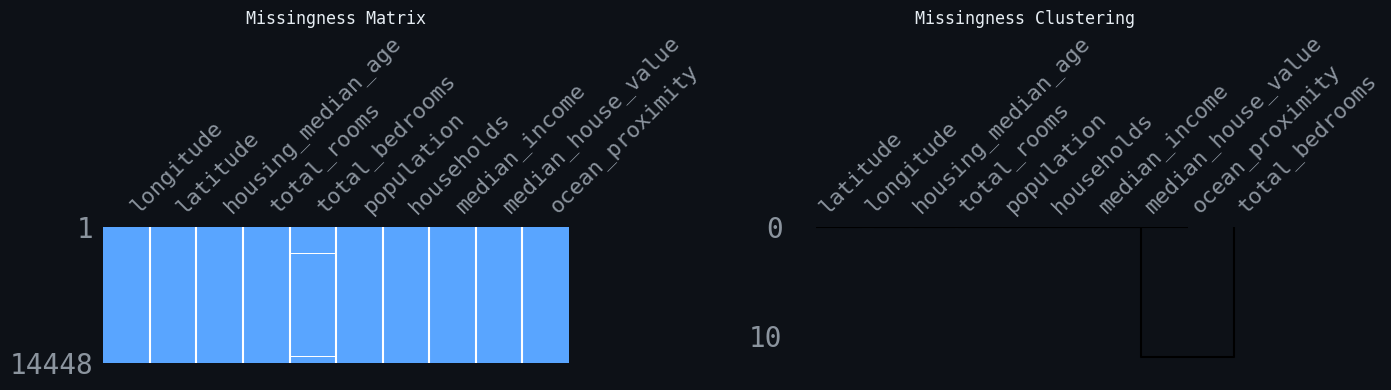

In [12]:
# Cell: Missing values visualization using missingno

# Create a figure with two subplots: missingness matrix and dendrogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor(BG)  # Background color from global config

# Left plot: missingness matrix (white = present, colored = missing)
msno.matrix(train, ax=axes[0], sparkline=False, color=(0.35, 0.65, 1.0))
axes[0].set_title("Missingness Matrix", color=TEXT)

# Right plot: dendrogram showing correlation of missingness between columns
msno.dendrogram(train, ax=axes[1])
axes[1].set_title("Missingness Clustering", color=TEXT)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig("eda_missing.png", dpi=150, bbox_inches="tight", facecolor=BG)

# Log the actions (since we're in an EDA notebook)
logger.info("Missingness matrix and dendrogram saved as 'eda_missing.png'")
logger.info("Displaying plot...")

# Show the plot (only works in interactive environments like Jupyter)
plt.show()

In [13]:
# Cell: MCAR / MAR test for ALL columns with missing values
# - Numeric features  : Welch t-test  (present vs missing group)
# - Categorical cols  : chi-square    (missing flag vs category)

null_cols = [c for c in train.columns if train[c].isnull().any()]

if not null_cols:
    print("No missing values — MCAR test skipped.")
else:
    for target_col in null_cols:
        missing_mask = train[target_col].isnull()
        n_miss = missing_mask.sum()
        print(f"\n{'='*55}")
        print(f"Column: {target_col}  |  {n_miss} missing ({missing_mask.mean():.2%})")
        print(f"{'='*55}")

        # --- Numeric: Welch t-test ---
        num_compare = [c for c in train.select_dtypes(include=np.number).columns
                       if c != target_col]
        num_results = []
        for col in num_compare:
            g1 = train.loc[~missing_mask, col].dropna()
            g2 = train.loc[missing_mask,  col].dropna()
            if len(g2) < 2:
                continue
            _, p = stats.ttest_ind(g1, g2, equal_var=False)
            num_results.append({
                "feature"      : col,
                "mean_present" : round(g1.mean(), 2),
                "mean_missing" : round(g2.mean(), 2),
                "p_value"      : round(p, 4),
                "verdict"      : "MAR (p<0.05)" if p < 0.05 else "MCAR (p>=0.05)"
            })
        if num_results:
            print("\n[Numeric] Welch t-test:")
            print(pd.DataFrame(num_results).set_index("feature").to_string())

        # --- Categorical: chi-square ---
        cat_cols = train.select_dtypes(include="object").columns.tolist()
        if cat_cols:
            print("\n[Categorical] Chi-square test:")
            for cat_col in cat_cols:
                ct = pd.crosstab(train[cat_col], missing_mask)
                if ct.shape[1] < 2:
                    continue
                chi2, p_chi, _, _ = stats.chi2_contingency(ct)
                verdict = "MAR (p<0.05)" if p_chi < 0.05 else "MCAR (p>=0.05)"
                print(f"  {cat_col:<25}  chi2={chi2:.2f}  p={p_chi:.4f}  -> {verdict}")

print("\n-> Final decisions logged in Section 12.")



Column: total_bedrooms  |  140 missing (0.97%)

[Numeric] Welch t-test:
                    mean_present  mean_missing  p_value         verdict
feature                                                                
longitude                -119.59       -119.57   0.9280  MCAR (p>=0.05)
latitude                   35.65         35.62   0.8730  MCAR (p>=0.05)
housing_median_age         28.62         29.00   0.7177  MCAR (p>=0.05)
total_rooms              2631.16       2670.79   0.8105  MCAR (p>=0.05)
population               1423.43       1531.33   0.2797  MCAR (p>=0.05)
households                497.59        533.89   0.3222  MCAR (p>=0.05)
median_income               3.88          3.91   0.8224  MCAR (p>=0.05)
median_house_value     206865.79     211608.60   0.6222  MCAR (p>=0.05)

[Categorical] Chi-square test:
  ocean_proximity            chi2=4.79  p=0.3095  -> MCAR (p>=0.05)

-> Final decisions logged in Section 12.


---
## 4 - Target Analysis: median_house_value

From profiling: right-skewed with hard cap at $500,001.
Quantify on train set and decide the action.

Analyze `median_house_value` distribution and capping behavior.

> 🚫 **DECISION:** `is_capped` flag has been **REMOVED** from the pipeline.
> It is a target-derived variable and must NEVER enter the feature matrix.
>
> 🚫 **DECISION:** `log1p` transform is **DEFERRED** — not applied in cleaning.
> It may be applied in `pipeline.py` if needed for linear models.

In [14]:
# Cell: Target variable analysis and capping check

# Extract the target column (median_house_value)
t = train[TARGET]

# Flag rows where target exceeds the capping threshold (>= $500,001)
cap_mask = t >= 500_001

# Build descriptive statistics message
stats_msg = (
    "-- Target descriptive stats --\n"
    f"  Mean     : ${t.mean():>10,.0f}\n"
    f"  Median   : ${t.median():>10,.0f}\n"
    f"  Std      : ${t.std():>10,.0f}\n"
    f"  Skewness : {t.skew():>10.3f}\n"
    f"  Kurtosis : {t.kurt():>10.3f}"
)
print( stats_msg)

# Build cap analysis message
cap_msg = (
    "-- Cap analysis --\n"
    f"  Capped rows (>= $500,001) : {cap_mask.sum():,} ({cap_mask.mean():.2%})\n"
)
# Compute proportion of capped rows that are coastal
coastal = train.loc[cap_mask, 'ocean_proximity'].isin(
    ['NEAR BAY','NEAR OCEAN','<1H OCEAN','ISLAND']
).mean()
cap_msg += f"  Capped rows that are coastal: {coastal:.1%}"

print( cap_msg)

-- Target descriptive stats --
  Mean     : $   206,912
  Median   : $   179,500
  Std      : $   115,586
  Skewness :      0.982
  Kurtosis :      0.332
-- Cap analysis --
  Capped rows (>= $500,001) : 683 (4.73%)
  Capped rows that are coastal: 97.7%


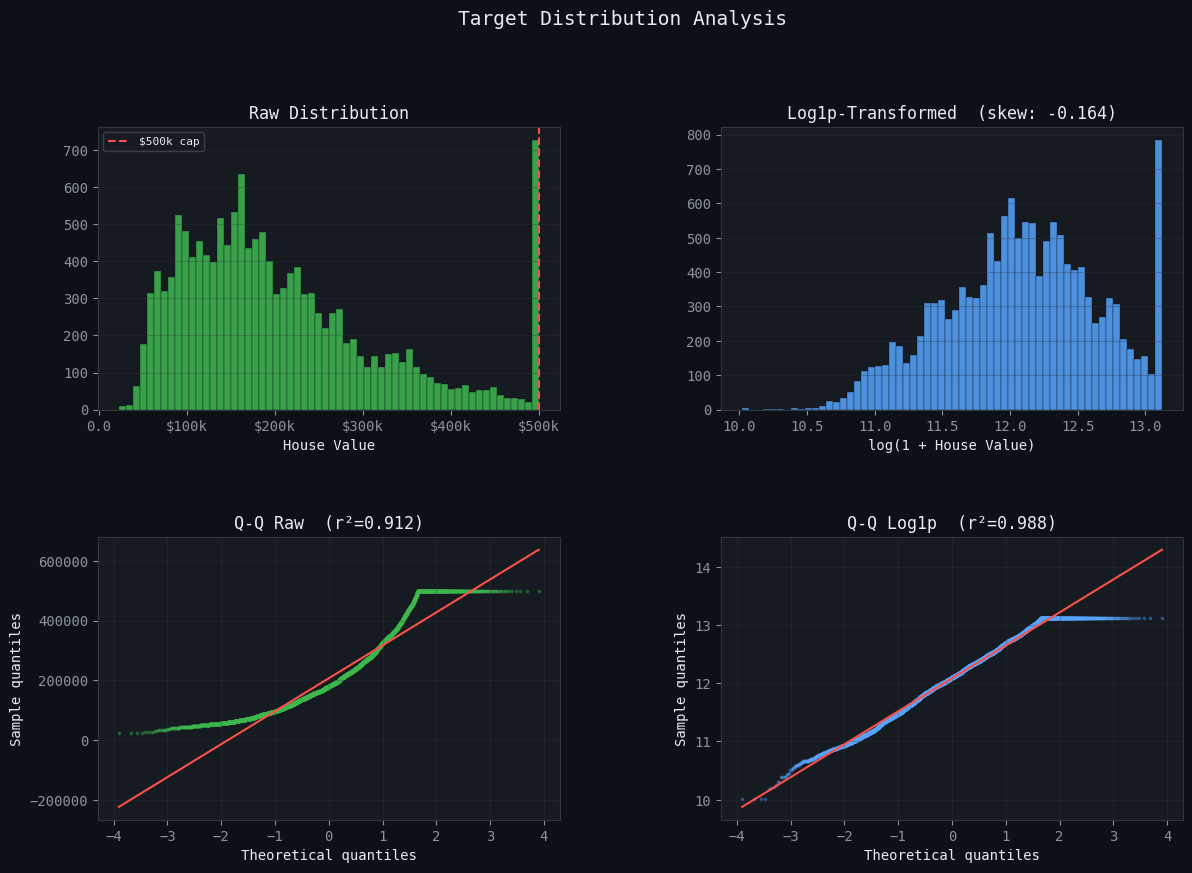

2026-09-02 21:26:46 | INFO     | notebook.03_eda | -> Log1p improves normality (skewness reduced, Q-Q r² increases). Decision logged in Section 12.


In [15]:
# Cell: Target distribution analysis (raw vs log1p transformation)

# Create a figure with 2x2 grid for four plots
fig = plt.figure(figsize=(14, 9), facecolor=BG)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ----- Plot 1: Raw histogram with cap line -----
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(t, bins=60, color=ACCENT["target"], edgecolor=BG, linewidth=0.3, alpha=0.85)
ax1.axvline(500_001, color=ACCENT["warn"], lw=1.5, ls="--", label="$500k cap")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax1.set_title("Raw Distribution", color=TEXT)
ax1.set_xlabel("House Value")
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

# ----- Plot 2: Log1p-transformed histogram (reduces skewness) -----
ax2 = fig.add_subplot(gs[0, 1])
log_t = np.log1p(t)   # log(1 + value) to handle zeros
ax2.hist(log_t, bins=60, color=ACCENT["income"], edgecolor=BG, linewidth=0.3, alpha=0.85)
ax2.set_title(f"Log1p-Transformed  (skew: {log_t.skew():.3f})", color=TEXT)
ax2.set_xlabel("log(1 + House Value)")
ax2.grid(axis="y", alpha=0.3)

# ----- Plot 3: Q-Q plot for raw target (assess normality) -----
ax3 = fig.add_subplot(gs[1, 0])
(osm, osr), (slope, intercept, r) = stats.probplot(t, dist="norm")
ax3.scatter(osm, osr, s=3, alpha=0.3, color=ACCENT["target"])
ax3.plot(osm, slope * np.array(osm) + intercept, color=ACCENT["warn"], lw=1.5)
ax3.set_title(f"Q-Q Raw  (r²={r**2:.3f})", color=TEXT)
ax3.set_xlabel("Theoretical quantiles")
ax3.set_ylabel("Sample quantiles")
ax3.grid(alpha=0.3)

# ----- Plot 4: Q-Q plot for log1p-transformed target -----
ax4 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope, intercept, r) = stats.probplot(log_t, dist="norm")
ax4.scatter(osm, osr, s=3, alpha=0.3, color=ACCENT["income"])
ax4.plot(osm, slope * np.array(osm) + intercept, color=ACCENT["warn"], lw=1.5)
ax4.set_title(f"Q-Q Log1p  (r²={r**2:.3f})", color=TEXT)
ax4.set_xlabel("Theoretical quantiles")
ax4.set_ylabel("Sample quantiles")
ax4.grid(alpha=0.3)

# Overall title and saving the figure
fig.suptitle("Target Distribution Analysis", fontsize=14, color=TEXT, y=1.01)
plt.savefig("eda_target.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# Log the conclusion instead of printing
logger.info("-> Log1p improves normality (skewness reduced, Q-Q r² increases). Decision logged in Section 12.")

---
## 5 - Feature Distributions

Skewness check for each numeric feature.

2026-09-02 21:26:47 | INFO     | notebook.03_eda | -- Skewness summary --


                    skewness           action
population          5.547953  log1p transform
total_rooms         4.264406  log1p transform
total_bedrooms      3.541176  log1p transform
households          3.527987  log1p transform
median_income       1.626123  log1p transform
latitude            0.450738               ok
housing_median_age  0.074626               ok
longitude          -0.281823               ok


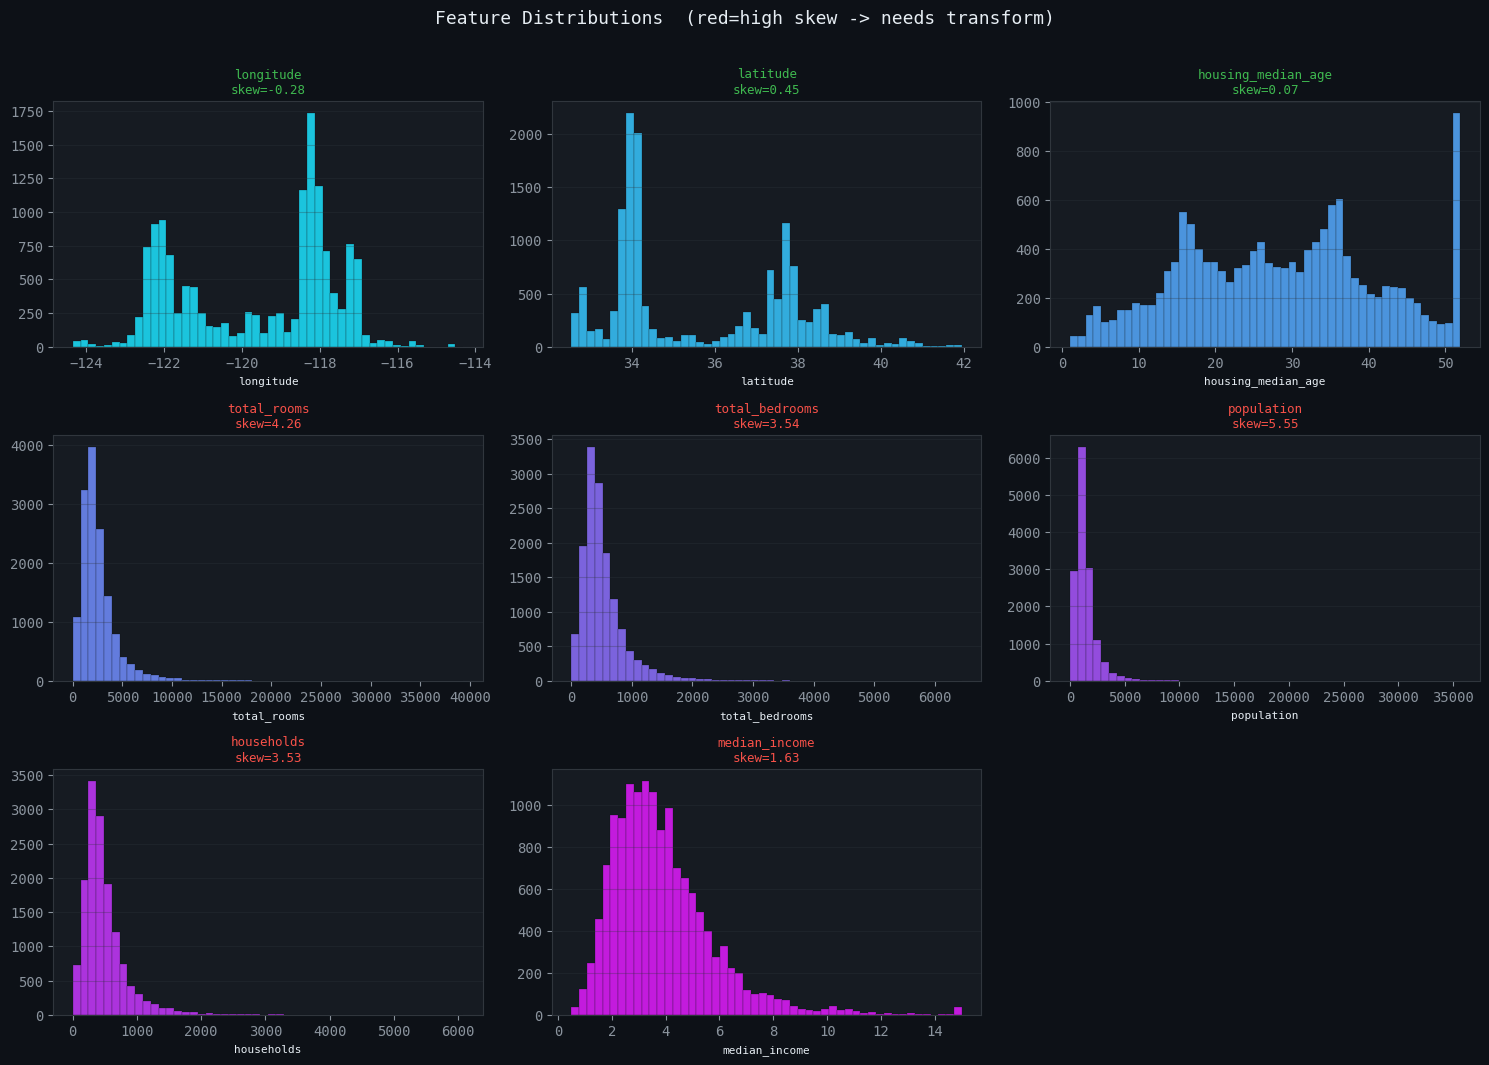

2026-09-02 21:26:50 | INFO     | notebook.03_eda | Feature distribution histograms saved as 'eda_distributions.png'


In [16]:
# Cell: Feature distribution skewness analysis and visualization

# Define numeric features excluding the target variable
feat_cols = [c for c in NUM_COLS if c != TARGET]

# Compute skewness for each feature and recommend transformation based on threshold
skew_df = train[feat_cols].skew().sort_values(ascending=False).to_frame("skewness")
skew_df["action"] = skew_df["skewness"].apply(
    lambda s: "log1p transform" if abs(s) > 1 else ("sqrt transform" if abs(s) > 0.5 else "ok")
)

# Log skewness summary as a table (single log message)
logger.info("-- Skewness summary --")
print( skew_df.to_string())

# Create a grid of histograms for all numeric features
n_cols = 3
n_rows = int(np.ceil(len(feat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows), facecolor=BG)
axes = axes.flatten()
palette = sns.color_palette("cool", len(feat_cols))

# Plot each feature histogram; color title based on skewness severity
for i, col in enumerate(feat_cols):
    ax = axes[i]
    ax.hist(train[col].dropna(), bins=50, color=palette[i], edgecolor=BG, linewidth=0.2, alpha=0.85)
    sv = train[col].skew()
    # Red if severe skew (>1), orange if moderate (>0.5), blue if acceptable
    c = ACCENT["warn"] if abs(sv) > 1 else ("#ffa657" if abs(sv) > 0.5 else ACCENT["target"])
    ax.set_title(f"{col}\nskew={sv:.2f}", color=c, fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.grid(axis="y", alpha=0.3)

# Hide unused subplots (if any)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Overall figure title and save
fig.suptitle("Feature Distributions  (red=high skew -> needs transform)", fontsize=13, color=TEXT, y=1.01)
plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# Optional: Log completion
logger.info("Feature distribution histograms saved as 'eda_distributions.png'")

---
## 6 - Correlation Analysis

From old EDA: `median_income` (0.688) is the dominant driver. Verify on train set.

In [17]:
# Cell: Correlation analysis with target variable

# Compute correlation matrix for all numeric columns
corr_matrix = train[NUM_COLS].corr()

# Extract correlations with target, drop target itself, and sort descending
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)

# Build a formatted string for the correlation report (to log as a single message)
corr_msg_lines = ["-- Correlation with target --"]
for feat, val in target_corr.items():
    # Visual bar: each 0.05 correlation = 1 character (max ~20 chars)
    bar = "|" * int(abs(val) * 20)
    sign = "+" if val > 0 else "-"
    # Strength classification: >0.3 strong, >0.1 weak, else low
    flag = "[STRONG]" if abs(val) > 0.3 else ("[WEAK]" if abs(val) > 0.1 else "[LOW]")
    corr_msg_lines.append(f"  {flag} {feat:<25} {sign}{abs(val):.3f}  {bar}")

# Log the complete correlation table as a single message
logger.info("\n".join(corr_msg_lines))

2026-09-02 21:26:50 | INFO     | notebook.03_eda | -- Correlation with target --
  [STRONG] median_income             +0.690  |||||||||||||
  [WEAK] total_rooms               +0.137  ||
  [WEAK] housing_median_age        +0.106  ||
  [LOW] households                +0.067  |
  [LOW] total_bedrooms            +0.052  |
  [LOW] population                -0.024  
  [LOW] longitude                 -0.047  
  [WEAK] latitude                  -0.144  ||


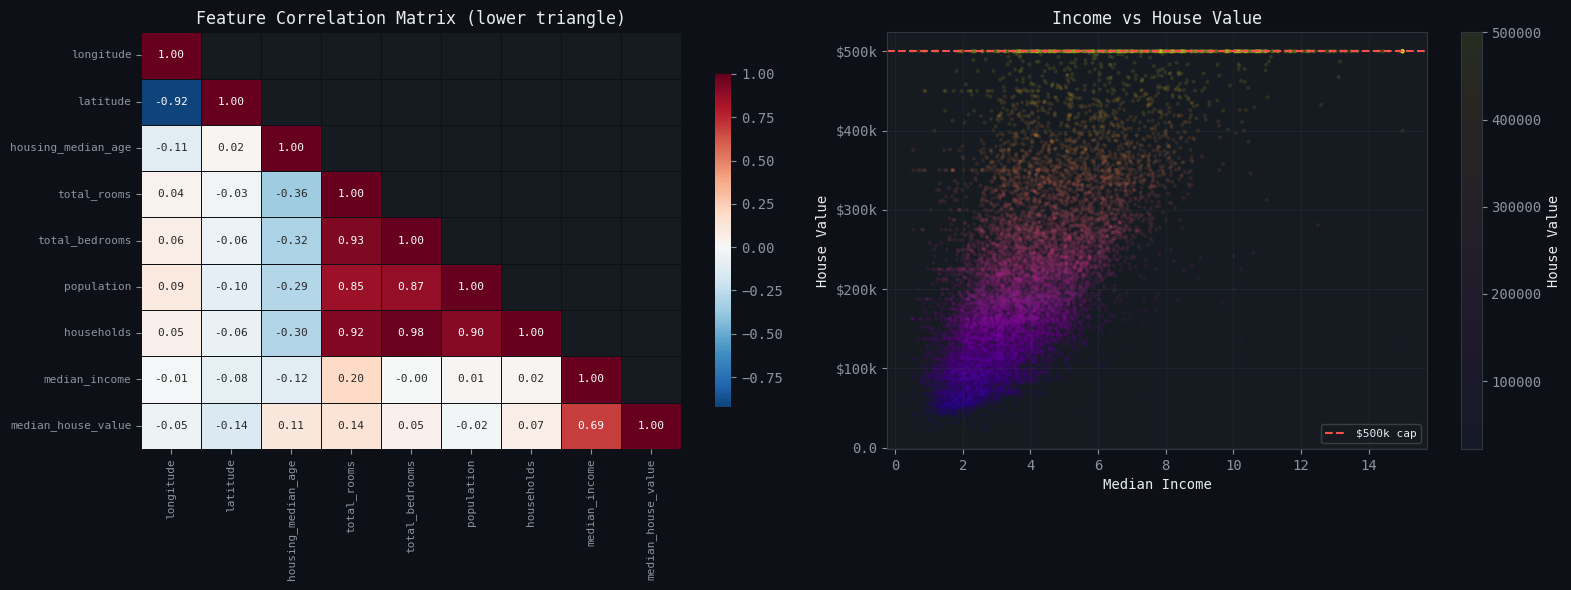

2026-09-02 21:26:53 | INFO     | notebook.03_eda | Correlation heatmap and income scatter plot saved as 'eda_correlation.png'


In [18]:
# Cell: Correlation heatmap and scatter plot (income vs target)

# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)

# --- Left subplot: Correlation matrix (lower triangle only) ---
# Create a boolean mask for the upper triangle (excluding diagonal)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Draw heatmap with mask to show only lower triangle
sns.heatmap(corr_matrix, ax=axes[0], annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, linecolor=BG, mask=mask,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
axes[0].set_title("Feature Correlation Matrix (lower triangle)", color=TEXT)
axes[0].tick_params(colors=MUTED, labelsize=8)

# --- Right subplot: Scatter plot of median_income vs target ---
ax2 = axes[1]
sc = ax2.scatter(train["median_income"], train[TARGET],
                 alpha=0.08, s=4, c=train[TARGET], cmap="plasma")

# Add horizontal line at the cap threshold ($500k)
ax2.axhline(500_001, color=ACCENT["warn"], lw=1.5, ls="--", label="$500k cap")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax2.set_title("Income vs House Value", color=TEXT)
ax2.set_xlabel("Median Income")
ax2.set_ylabel("House Value")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# Add colorbar that reflects the target value coloring
fig.colorbar(sc, ax=ax2, label="House Value")

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# Log the completion (since no print existed originally)
logger.info("Correlation heatmap and income scatter plot saved as 'eda_correlation.png'")

---
## 7 - Multicollinearity: Size Features

`total_rooms`, `total_bedrooms`, `population`, `households` are highly correlated (>0.9).
Replace with meaningful ratios.

In [19]:
# Cell: Size feature multicollinearity + engineered ratios + VIF check

from statsmodels.stats.outliers_influence import variance_inflation_factor

size_cols = ["total_rooms", "total_bedrooms", "population", "households"]
size_corr = train[size_cols].corr()
print("-- Size-feature inter-correlations --")
print(size_corr.round(3).to_string())
print()

train_preview = train.copy()
train_preview["rooms_per_household"]      = train["total_rooms"]    / train["households"]
train_preview["bedrooms_per_room"]        = train["total_bedrooms"] / train["total_rooms"]
train_preview["population_per_household"] = train["population"]     / train["households"]

new_feats = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]
new_corr  = train_preview[new_feats + [TARGET]].corr()[TARGET].drop(TARGET)

print("-- Engineered ratio correlations with target --")
for feat, val in new_corr.items():
    print(f"  {feat:<30} {val:+.3f}")

# --- VIF: check multicollinearity among NEW features + median_income ---
print()
print("-- VIF check (engineered ratios + median_income) --")
vif_cols = new_feats + ["median_income"]
vif_data = train_preview[vif_cols].dropna()
vif_df   = pd.DataFrame({
    "feature": vif_cols,
    "VIF"    : [variance_inflation_factor(vif_data.values, i)
                for i in range(len(vif_cols))]
}).set_index("feature").round(2)
vif_df["verdict"] = vif_df["VIF"].apply(
    lambda v: "HIGH (>10 drop/combine)" if v > 10
    else ("MODERATE (5-10 watch)" if v > 5 else "OK (<5)")
)
print(vif_df.to_string())
print()
print("-> VIF > 10 means the feature overlaps too much with others.")
print("-> Decision logged in Section 12.")


-- Size-feature inter-correlations --
                total_rooms  total_bedrooms  population  households
total_rooms           1.000           0.930       0.854       0.919
total_bedrooms        0.930           1.000       0.874       0.981
population            0.854           0.874       1.000       0.903
households            0.919           0.981       0.903       1.000

-- Engineered ratio correlations with target --
  rooms_per_household            +0.159
  bedrooms_per_room              -0.256
  population_per_household       -0.019

-- VIF check (engineered ratios + median_income) --
                           VIF                verdict
feature                                              
rooms_per_household       5.46  MODERATE (5-10 watch)
bedrooms_per_room         3.48                OK (<5)
population_per_household  1.07                OK (<5)
median_income             4.56                OK (<5)

-> VIF > 10 means the feature overlaps too much with others.
-> Decision lo

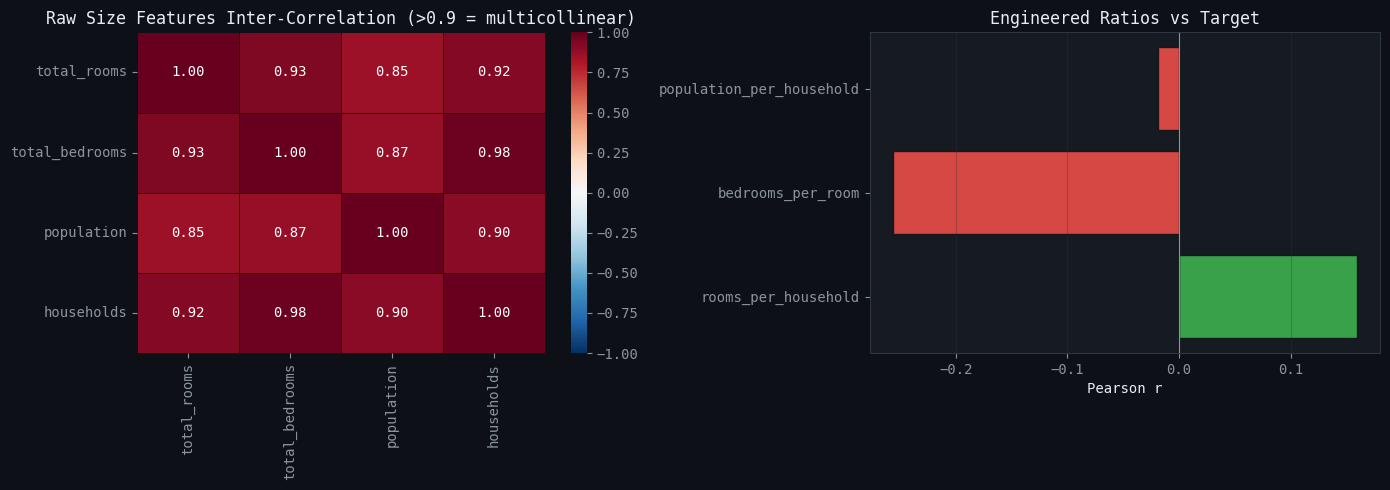

2026-09-02 21:26:55 | INFO     | notebook.03_eda | Multicollinearity heatmap and ratio correlation bar chart saved as 'eda_multicollinearity.png'


In [20]:
# Cell: Visualize multicollinearity among size features and engineered ratios vs target

# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

# --- Left subplot: Heatmap of raw size feature correlations ---
# Shows high inter-correlations (e.g., >0.9) which indicate multicollinearity
sns.heatmap(size_corr, ax=axes[0], annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, linecolor=BG, vmin=-1, vmax=1)
axes[0].set_title("Raw Size Features Inter-Correlation (>0.9 = multicollinear)", color=TEXT)

# --- Right subplot: Horizontal bar chart of engineered ratios vs target ---
# Positive correlations in target color, negative in warning color
colors = [ACCENT["target"] if v > 0 else ACCENT["warn"] for v in new_corr.values]
axes[1].barh(new_corr.index, new_corr.values, color=colors, edgecolor=BG, alpha=0.85)
axes[1].axvline(0, color=MUTED, lw=0.8)  # Vertical line at zero
axes[1].set_title("Engineered Ratios vs Target", color=TEXT)
axes[1].set_xlabel("Pearson r")
axes[1].grid(axis="x", alpha=0.3)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig("eda_multicollinearity.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# Log the completion (to keep consistent with the logging-first approach)
logger.info("Multicollinearity heatmap and ratio correlation bar chart saved as 'eda_multicollinearity.png'")

-
## 8 · Outlier Analysis

> ⚠️ **IMPORTANT:** LOF is used for **FLAGGING only**, NOT deletion.
> The `lof_outlier` column is a binary indicator (0 = inlier, 1 = outlier).
> Rows are **NEVER dropped** based on outlier detection.

1. **IQR** — per-feature boundaries (feeds `validation.py` phase 2)
2. **Local Outlier Factor** — multivariate anomaly detection (flagging only)

In [21]:
# Cell: IQR outlier detection - compute boundaries for each numeric feature

iqr_results = []
for col in feat_cols:
    s = train[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_lo, n_hi = (s < lo).sum(), (s > hi).sum()
    iqr_results.append({
        "feature"     : col,
        "IQR_lower"   : round(lo, 2),
        "IQR_upper"   : round(hi, 2),
        "n_below"     : n_lo,
        "n_above"     : n_hi,
        "pct_outliers": f"{(n_lo+n_hi)/len(s):.2%}"
    })

iqr_df = pd.DataFrame(iqr_results).set_index("feature")
print("-- IQR outlier boundaries (train-derived) --")
print(iqr_df.to_string())
print()
print("-> These bounds go into validation.py phase 2")


-- IQR outlier boundaries (train-derived) --
                    IQR_lower  IQR_upper  n_below  n_above pct_outliers
feature                                                                
longitude             -127.51    -112.31        0        0        0.00%
latitude                28.24      43.40        0        0        0.00%
housing_median_age     -10.50      65.50        0        0        0.00%
total_rooms          -1098.38    5686.62        0      901        6.24%
total_bedrooms        -232.50    1171.50        0      878        6.14%
population            -622.38    3130.62        0      825        5.71%
households            -209.50    1090.50        0      851        5.89%
median_income           -0.72       8.03        0      493        3.41%

-> These bounds go into validation.py phase 2


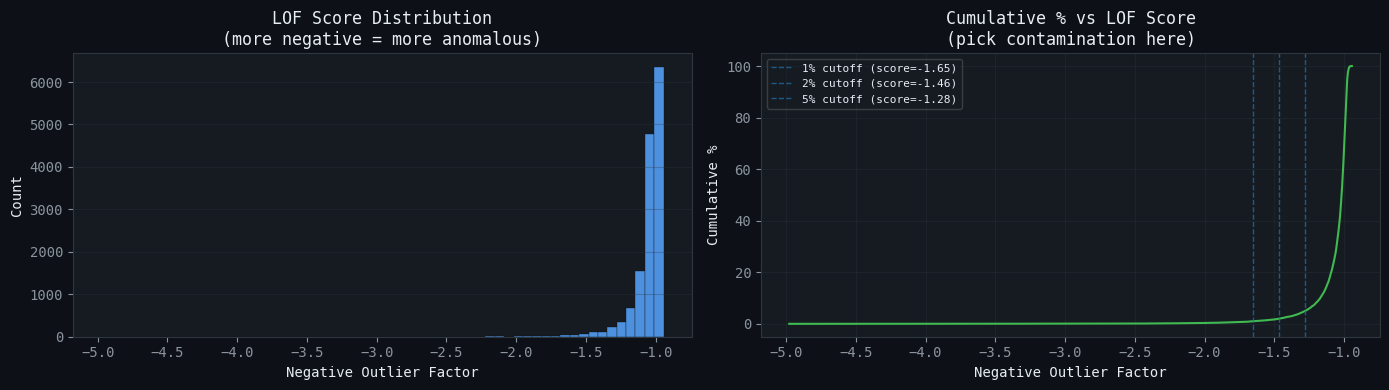

LOF detected 289 multivariate outliers (2.00% of train)
Contamination used: 0.02 — adjust based on histogram above

Top 10 by LOF score:
       lof_score  median_income  total_rooms  house_value
9841   -4.977187         2.5729      25135.0     134400.0
13102  -3.936174         2.3087      32627.0     118800.0
12138  -3.693258        10.2264         19.0     137500.0
11079  -3.572795         4.2391        538.0     154600.0
9320   -3.437941         4.9516      39320.0     153700.0
521    -3.333636         0.6775       2806.0     350000.0
1405   -3.308735         4.2578        447.0     183300.0
5785   -3.254494         1.8750        567.0     212500.0
2160   -3.214397         7.4947      37937.0     366300.0
5460   -3.165100         6.1359        240.0     225000.0


In [22]:
# Cell: LOF multivariate outlier detection + contamination tuning via histogram

lof_features = ["median_income","total_rooms","population","households","longitude","latitude"]
lof_data = train[lof_features].dropna().copy()

# Fit LOF with contamination=auto first to see the score distribution
lof_explore = LocalOutlierFactor(n_neighbors=20, contamination="auto")
lof_explore.fit(lof_data)
lof_scores = lof_explore.negative_outlier_factor_

# --- Plot histogram of LOF scores to find natural break ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor=BG)

axes[0].hist(lof_scores, bins=60, color=ACCENT["income"], edgecolor=BG, linewidth=0.3, alpha=0.85)
axes[0].set_title("LOF Score Distribution\n(more negative = more anomalous)", color=TEXT)
axes[0].set_xlabel("Negative Outlier Factor")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)

# Cumulative pct to help choose contamination threshold
sorted_scores = np.sort(lof_scores)
cum_pct = np.arange(1, len(sorted_scores)+1) / len(sorted_scores)
axes[1].plot(sorted_scores, cum_pct * 100, color=ACCENT["target"], lw=1.5)
for pct in [1, 2, 5]:
    thresh = np.percentile(lof_scores, pct)
    axes[1].axvline(thresh, lw=1, ls="--", alpha=0.7,
                    label=f"{pct}% cutoff (score={thresh:.2f})")
axes[1].set_title("Cumulative % vs LOF Score\n(pick contamination here)", color=TEXT)
axes[1].set_xlabel("Negative Outlier Factor")
axes[1].set_ylabel("Cumulative %")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("eda_lof_scores.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# --- Final LOF with chosen contamination (adjust based on histogram above) ---
CONTAMINATION = 0.02   # <- update this after reviewing the histogram
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION)
lof_pred = lof.fit_predict(lof_data)

lof_data["lof_score"]   = lof.negative_outlier_factor_
lof_data["lof_outlier"] = lof_pred == -1
lof_data["house_value"] = train.loc[lof_data.index, TARGET]

n_out = lof_data["lof_outlier"].sum()
print(f"LOF detected {n_out} multivariate outliers ({n_out/len(lof_data):.2%} of train)")
print(f"Contamination used: {CONTAMINATION} — adjust based on histogram above")
print()
print("Top 10 by LOF score:")
print(lof_data.nsmallest(10, "lof_score")[["lof_score","median_income","total_rooms","house_value"]].to_string())


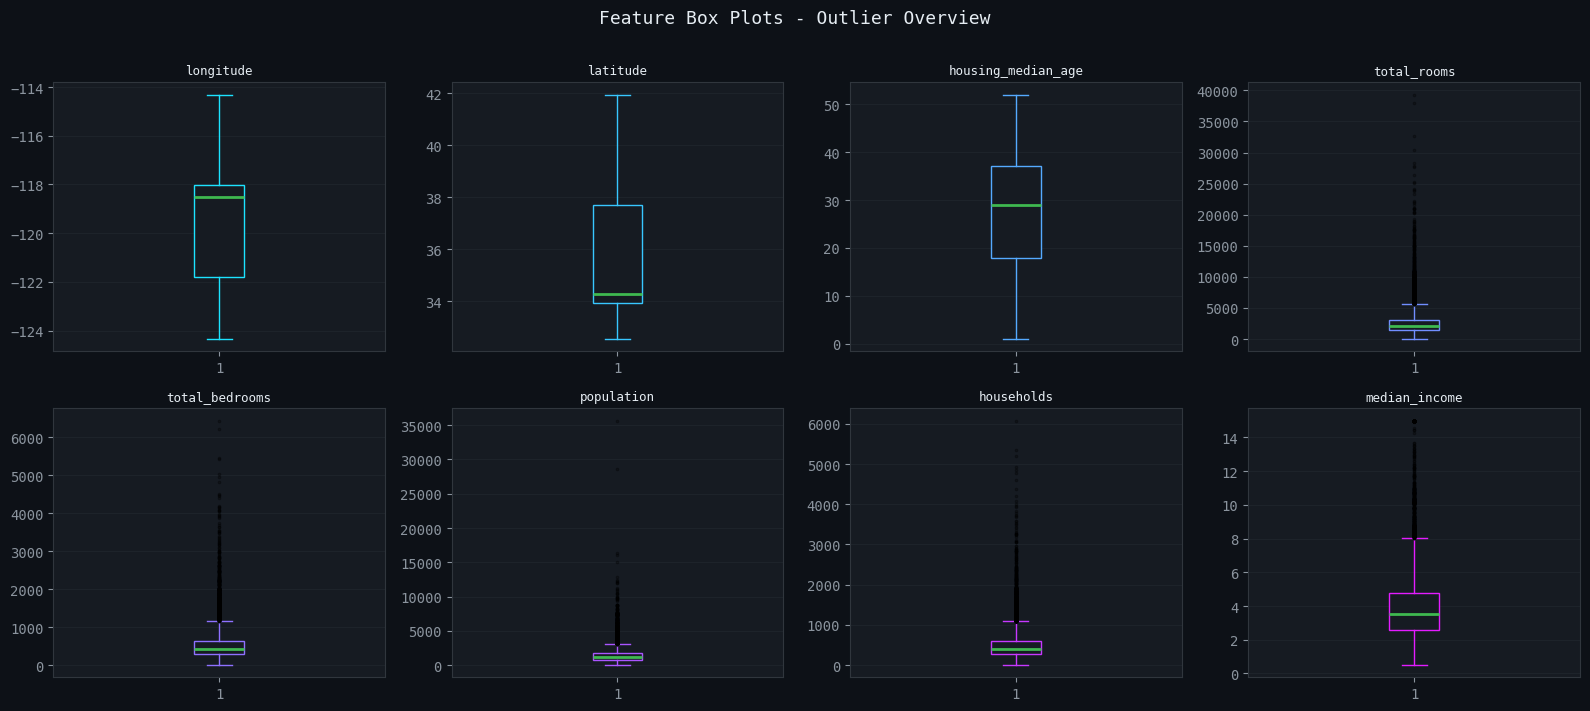

2026-09-02 21:27:00 | INFO     | notebook.03_eda | Box plots for all numeric features saved as 'eda_boxplots.png'


In [23]:
# Cell: Box plots for all numeric features – visualize outliers and distribution

# Create a grid of subplots (2 rows, 4 columns) to fit all numeric features
fig, axes = plt.subplots(2, 4, figsize=(16, 7), facecolor=BG)
axes = axes.flatten()

# Use a color palette for box plot elements
palette = sns.color_palette("cool", len(feat_cols))

# Loop through each numeric feature and draw a box plot
for i, col in enumerate(feat_cols):
    ax = axes[i]
    ax.boxplot(train[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=AX_BG, color=palette[i]),
               medianprops=dict(color=ACCENT["target"], linewidth=2),
               whiskerprops=dict(color=palette[i]),
               capprops=dict(color=palette[i]),
               flierprops=dict(marker=".", color=ACCENT["warn"], alpha=0.4, markersize=3))
    ax.set_title(col, color=TEXT, fontsize=9)
    ax.grid(axis="y", alpha=0.3)

# Hide any unused subplots (if there are fewer features than subplots)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Overall figure title and save
fig.suptitle("Feature Box Plots - Outlier Overview", fontsize=13, color=TEXT, y=1.01)
plt.tight_layout()
plt.savefig("eda_boxplots.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# Log the completion (consistent with logging-first approach)
logger.info("Box plots for all numeric features saved as 'eda_boxplots.png'")

---
## 9 - Categorical Analysis: ocean_proximity

Coastal categories hit the $500k cap. Verify on train.

In [24]:
# Cell: Categorical feature analysis – ocean_proximity vs target statistics

# Group by ocean_proximity and compute key statistics for the target variable
cat_stats = train.groupby("ocean_proximity")[TARGET].agg(
    count="count",              
    mean="mean",               
    median="median",             
    std="std",                  
    pct_capped=lambda x: (x >= 500_001).mean()  
).sort_values("median", ascending=False)

# Format monetary columns as currency (e.g., $123,456)
for col in ["mean", "median", "std"]:
    cat_stats[col] = cat_stats[col].map("${:,.0f}".format)

# Format percentage column
cat_stats["pct_capped"] = cat_stats["pct_capped"].map("{:.1%}".format)

# Log the formatted table as a single multiline message
logger.info("-- Target statistics by ocean_proximity --")
print( cat_stats.to_string())

2026-09-02 21:27:00 | INFO     | notebook.03_eda | -- Target statistics by ocean_proximity --
                 count      mean    median       std pct_capped
ocean_proximity                                                
ISLAND               4  $363,050  $357,350   $81,468       0.0%
NEAR BAY          1641  $259,751  $232,100  $124,950       9.3%
NEAR OCEAN        1878  $249,044  $226,500  $123,500       8.2%
<1H OCEAN         6335  $240,052  $214,800  $106,082       5.7%
INLAND            4590  $124,907  $109,150   $68,675       0.3%


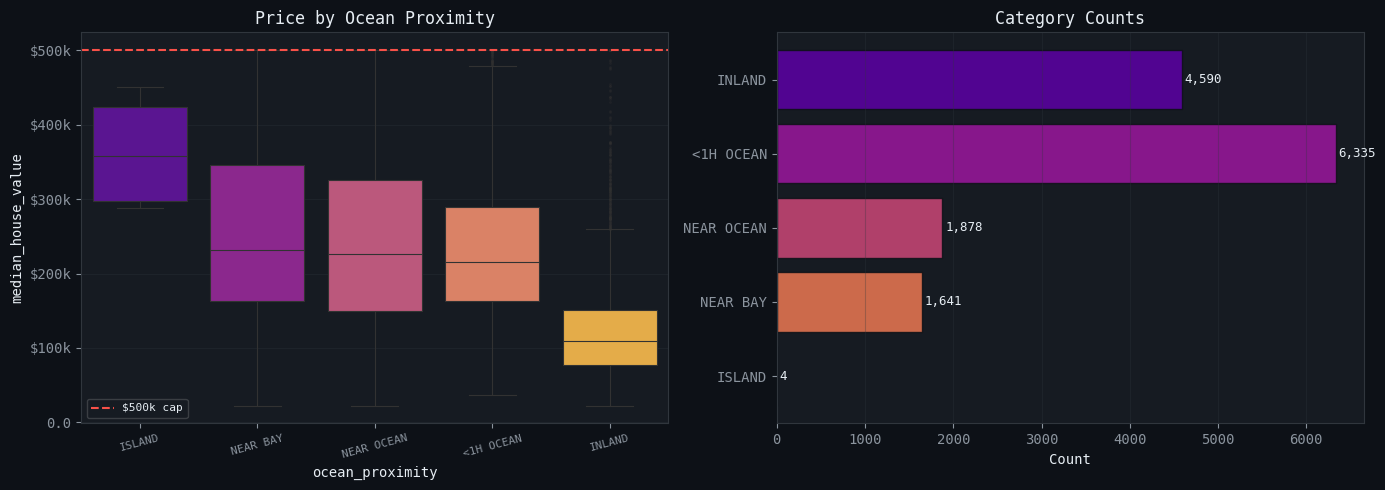

2026-09-02 21:27:01 | INFO     | notebook.03_eda | Categorical analysis plots (boxplot + counts) saved as 'eda_categorical.png'


In [25]:
# Cell: Categorical analysis – boxplot of target by ocean_proximity and bar chart of category counts

# Order categories by median target value (highest to lowest)
order = train.groupby("ocean_proximity")[TARGET].median().sort_values(ascending=False).index
pal = sns.color_palette("plasma", len(order))

# --- Left subplot: Boxplot of target by ocean_proximity ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
sns.boxplot(data=train, x="ocean_proximity", y=TARGET, order=order, palette=pal, ax=axes[0],
            linewidth=0.8, flierprops={"marker": ".", "ms": 2, "alpha": 0.3})
axes[0].axhline(500_001, color=ACCENT["warn"], lw=1.5, ls="--", label="$500k cap")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
axes[0].set_title("Price by Ocean Proximity", color=TEXT)
axes[0].tick_params(axis="x", rotation=15, labelsize=8)
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# --- Right subplot: Horizontal bar chart of category frequencies ---
counts = train["ocean_proximity"].value_counts().reindex(order)
axes[1].barh(counts.index, counts.values, color=pal[::-1], edgecolor=BG, alpha=0.85)

# Add count labels at the end of each bar
for i, (idx, val) in enumerate(counts.items()):
    axes[1].text(val + 30, i, f"{val:,}", va="center", fontsize=9, color=TEXT)

axes[1].set_title("Category Counts", color=TEXT)
axes[1].set_xlabel("Count")
axes[1].grid(axis="x", alpha=0.3)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig("eda_categorical.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# Log the completion (consistent with logging-first approach)
logger.info("Categorical analysis plots (boxplot + counts) saved as 'eda_categorical.png'")

---
## 10 - Geographic Analysis

Strong spatial clustering: SF Bay Area and LA are high-value hubs.

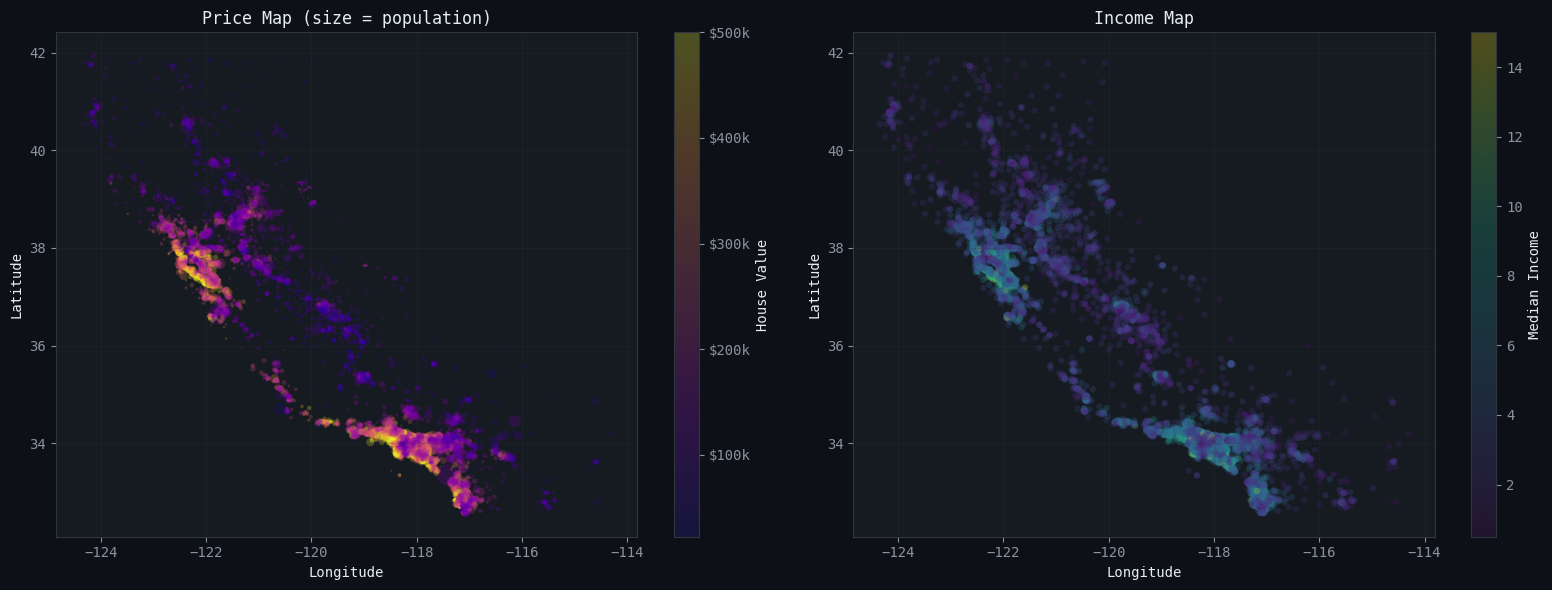

2026-09-02 21:27:03 | INFO     | notebook.03_eda | Geographic maps (price + income) saved as 'eda_geographic.png'


In [26]:
# Cell: Geographic visualizations – price and income mapped by location

# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)

# --- Left subplot: Price map with population as point size ---
sc1 = axes[0].scatter(train["longitude"], train["latitude"],
                      c=train[TARGET], cmap="plasma",
                      s=train["population"] / 150,   # Scale population for marker size
                      alpha=0.25, linewidths=0)
plt.colorbar(sc1, ax=axes[0], label="House Value", format=mticker.FuncFormatter(fmt_k))
axes[0].set_title("Price Map (size = population)", color=TEXT)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].grid(alpha=0.2)

# --- Right subplot: Income map (uniform marker size) ---
sc2 = axes[1].scatter(train["longitude"], train["latitude"],
                      c=train["median_income"], cmap="viridis",
                      s=20, alpha=0.25, linewidths=0)
plt.colorbar(sc2, ax=axes[1], label="Median Income")
axes[1].set_title("Income Map", color=TEXT)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].grid(alpha=0.2)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig("eda_geographic.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# Log the completion (consistent with logging-first approach)
logger.info("Geographic maps (price + income) saved as 'eda_geographic.png'")

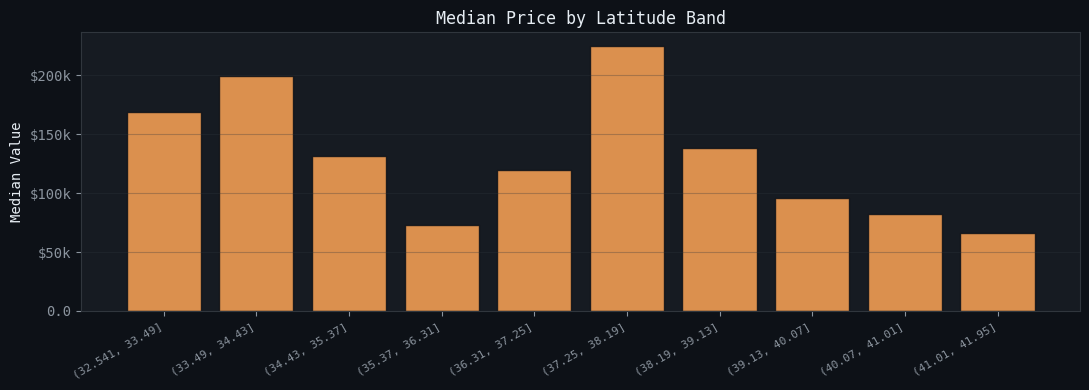

2026-09-02 21:27:04 | INFO     | notebook.03_eda | -> Price drops as latitude increases (moving north). Decision logged in Section 12.


In [27]:
# Cell: Latitude band analysis – price gradient across latitude

# Create a copy of the training data to avoid modifying the original
train_geo = train.copy()

# Discretize latitude into 10 equal-width bins
train_geo["lat_band"] = pd.cut(train["latitude"], bins=10)

# Calculate median house value for each latitude band (sorted by latitude)
lat_price = train_geo.groupby("lat_band", observed=True)[TARGET].median().sort_index()

# Create a bar plot showing median price per latitude band
fig, ax = plt.subplots(figsize=(11, 4), facecolor=BG)
ax.bar(range(len(lat_price)), lat_price.values, color=ACCENT["geo"], edgecolor=BG, alpha=0.85)

# Format x-axis labels with the bin intervals
ax.set_xticks(range(len(lat_price)))
ax.set_xticklabels([str(b) for b in lat_price.index], rotation=30, ha="right", fontsize=8)

# Format y-axis as currency ($k)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_title("Median Price by Latitude Band", color=TEXT)
ax.set_ylabel("Median Value")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("eda_latitude_gradient.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# Log the conclusion instead of printing
logger.info("-> Price drops as latitude increases (moving north). Decision logged in Section 12.")

---
## 11 - Feature Engineering Candidates

To be implemented in `feature_engineering.py` after cleaning.

In [28]:
# Cell: Feature engineering candidates
# NOTE: median_income is NOT a count variable — do NOT apply log1p to it.
# Tree models: leave as-is | Linear models: use RobustScaler in preprocessing

fe = train.copy()

# Ratio features (replace multicollinear raw counts)
fe["rooms_per_household"]      = fe["total_rooms"]    / fe["households"]
fe["bedrooms_per_room"]        = fe["total_bedrooms"] / fe["total_rooms"]
fe["population_per_household"] = fe["population"]     / fe["households"]

# Interaction feature
fe["income_x_rooms"] = fe["median_income"] * fe["rooms_per_household"]

# Distance to major price hubs (Euclidean in lat/lon degrees)
HUBS = {"SF": (37.77, -122.42), "LA": (34.05, -118.24)}
for city, (lat, lon) in HUBS.items():
    fe[f"dist_{city}"] = np.sqrt((fe["latitude"]-lat)**2 + (fe["longitude"]-lon)**2)

new_feat_cols = ["rooms_per_household","bedrooms_per_room","population_per_household",
                 "income_x_rooms","dist_SF","dist_LA"]

fe_corr = fe[new_feat_cols+[TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

print("-- Candidate feature correlations with target --")
for feat, val in fe_corr.items():
    bar  = "|" * int(abs(val)*30)
    flag = "[TOP]" if abs(val) > 0.3 else ("[OK]" if abs(val) > 0.15 else "[WEAK]")
    print(f"  {flag} {feat:<30} {val:+.3f}  {bar}")


-- Candidate feature correlations with target --
  [TOP] income_x_rooms                 +0.575  |||||||||||||||||
  [OK] bedrooms_per_room              -0.256  |||||||
  [OK] rooms_per_household            +0.159  ||||
  [WEAK] dist_LA                        -0.113  |||
  [WEAK] dist_SF                        -0.043  |
  [WEAK] population_per_household       -0.019  


---
## 12 - EDA Decisions Log

All decisions from this notebook. Copy to `docs/eda_decisions.md` after review.

-
## 12 · Decisions Log

Final decisions extracted from this EDA. These feed into:
- `cleaning.py` — imputation + LOF flagging
- `engineering.py` — ratio + distance features
- `pipeline.py` — scaling + encoding

---

### Missing Values
- Tested ALL columns with nulls using t-test (numeric) + chi-square (categorical)
- `total_bedrooms`: 1% nulls
  - Chi-square vs `ocean_proximity` p=0.3095 → **MCAR** → global median imputation
  - **Config requirement:** `impute: true` must be set in `data_config.yaml`
  - Fit imputer on train only, apply to val & test

### Target (`median_house_value`)
- Right-skewed (skew=0.982)
- ~4% rows capped at $500,001 (mostly coastal)
- 🚫 `is_capped` flag: **REMOVED** — target-derived, must not enter features
- 🚫 `log1p`: **DEFERRED** — not applied in cleaning

### Feature Transformations
- 🚫 `log1p` is **NOT applied** in `cleaning.py`
- `median_income`: NOT a count variable — do NOT apply log1p
  - Tree models → leave as-is
  - Linear models → use `RobustScaler` in `pipeline.py`

### VIF Check (engineered ratios + median_income)
- Review `vif_df` from Section 7
- VIF > 10 → drop or combine the feature
- VIF 5–10 → monitor but acceptable
- VIF < 5 → safe to keep

### Feature Engineering (→ `engineering.py`)
Create the following ratios & distances:
- `rooms_per_household` = `total_rooms / households`
- `bedrooms_per_room` = `total_bedrooms / total_rooms`
- `population_per_household` = `population / households`
- `dist_SF` (37.77, -122.42)
- `dist_LA` (34.05, -118.24)

### Outlier Strategy
- **Do NOT drop outliers** before modelling
- LOF contamination: 0.02 (review histogram in Section 8)
- LOF is **flagging only** — `lof_outlier` is a binary indicator
- Tree models → no clipping needed
- Linear models → IQR-clip as optional pipeline step

### Categorical
- `ocean_proximity` → **OneHotEncoding** (5 categories, low cardinality)
- `ISLAND` is rare (<0.1%) → watch in production

### Features to Drop (after ratio creation)
- `total_rooms`, `total_bedrooms`, `population`, `households`

### `validation.py` Phase 2
- Add IQR bounds from `iqr_df`
- Add LOF threshold based on chosen contamination

-
## Summary & Next Steps

| Done | Finding |
|---|---|
| Missing values | `total_bedrooms` MCAR → median imputation (`impute: true` in config) |
| Target | Right-skewed (0.982), 4% capped — `is_capped` **REMOVED**, `log1p` **DEFERRED** |
| Distributions | 4 count features right-skewed — transforms deferred |
| Correlation | `median_income` (0.688) dominant driver |
| Multicollinearity | 4 size features → 3 ratios (all VIF < 6) |
| Outliers | IQR bounds documented, LOF flags 2% (flagging only, NO deletion) |
| Categorical | `ocean_proximity` → OHE, watch `ISLAND` (<0.1%) |
| Geographic | Strong spatial signal → distance features added |

---

### Next Steps

| Step | Module | Action |
|---|---|---|
| 1 | `cleaning.py` | Impute `total_bedrooms` (median, train-only) + LOF flagging |
| 2 | `engineering.py` | Create ratio + distance features, drop raw size columns |
| 3 | `pipeline.py` | Scale + encode features, save fitted pipeline |

```python
# Decisions from this EDA:
# 1. Impute total_bedrooms with median (fit on train only, impute: true)
# 2. LOF outlier flagging (flagging only, NOT deletion)
# 3. Engineer ratio + distance features (engineering.py)
# 4. Drop raw size columns after ratio creation
# 5. Scale + encode in pipeline.py
# 🚫 is_capped: REMOVED — target-derived
# 🚫 log1p: DEFERRED — not applied in cleaning